In [95]:
import os 
import numpy as np
import PIL.Image as Image
import torch
import matplotlib.pyplot as plt
import cv2



In [96]:
ref = os.path.join("..", "data", "iapr-26-uno-vision-challenge", "reference_images")

In [ ]:
img_name = "L1000767"
img = Image.open(os.path.join(ref, f"{img_name}.jpg")).convert("L")
img_array = np.array(img)

# Create output folders
out_dir        = img_name
components_dir = os.path.join(out_dir, f"components_{img_name}")
closed_dir     = os.path.join(out_dir, f"closed_components_{img_name}")
crops_dir      = os.path.join(out_dir, f"crops_{img_name}")
for d in (components_dir, closed_dir, crops_dir):
    os.makedirs(d, exist_ok=True)

# threshold the image to create a binary mask
adaptive_image = cv2.adaptiveThreshold(
    img_array, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=11,
    C=4
)
# median blur to remove noise
adaptive_image = cv2.medianBlur(adaptive_image, 3)

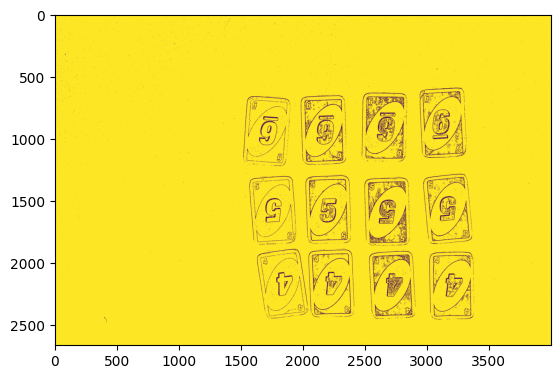

In [105]:
plt.imshow(adaptive_image)

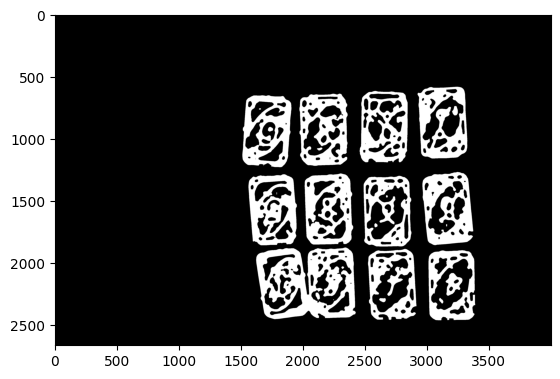

In [110]:
from skimage.morphology import skeletonize
# Find contours from the thresholded image and save one mask per detected object
binary = adaptive_image.copy()

# cv2.findContours expects white foreground on black background.
# If most pixels are white, foreground is likely black -> invert.
if np.mean(binary == 255) > 0.5:
    binary = cv2.bitwise_not(binary)

# despeckle
#binary = cv2.medianBlur(binary, 23)

# Remove tiny speckles and close small gaps to stabilize contours
kernel = np.ones((17, 17), np.uint8)
binary = cv2.morphologyEx(binary, cv2.MORPH_DILATE, kernel)


# skeletonize returns bool; convert to uint8 for OpenCV ops
binary = skeletonize(binary > 0).astype(np.uint8) * 255
kernel = np.ones((17, 17), np.uint8)
# close the contours with a smaller kernel
binary = cv2.morphologyEx(binary, cv2.MORPH_DILATE, kernel)
binary = cv2.medianBlur(binary, 33)


#binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
# remove small white dots by computing area of contours and removing those with area < 1000
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:    
    if cv2.contourArea(contour) < 100000:
        cv2.drawContours(binary, [contour], -1, 0, thickness=cv2.FILLED)

plt.imshow(binary, cmap='gray')

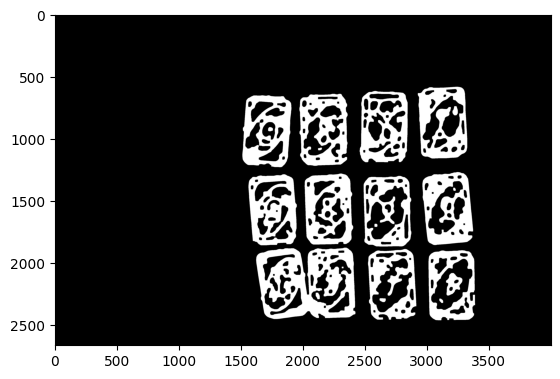

In [114]:
masks = binary.copy()
kernel = np.ones((13, 13), np.uint8)
masks = cv2.morphologyEx(masks, cv2.MORPH_OPEN, kernel)
kernel = np.ones((13, 13), np.uint8)
masks = cv2.morphologyEx(masks, cv2.MORPH_CLOSE, kernel)
kernel = np.ones((13, 13), np.uint8)
masks = cv2.morphologyEx(masks, cv2.MORPH_OPEN, kernel)

plt.imshow(masks, cmap='gray')

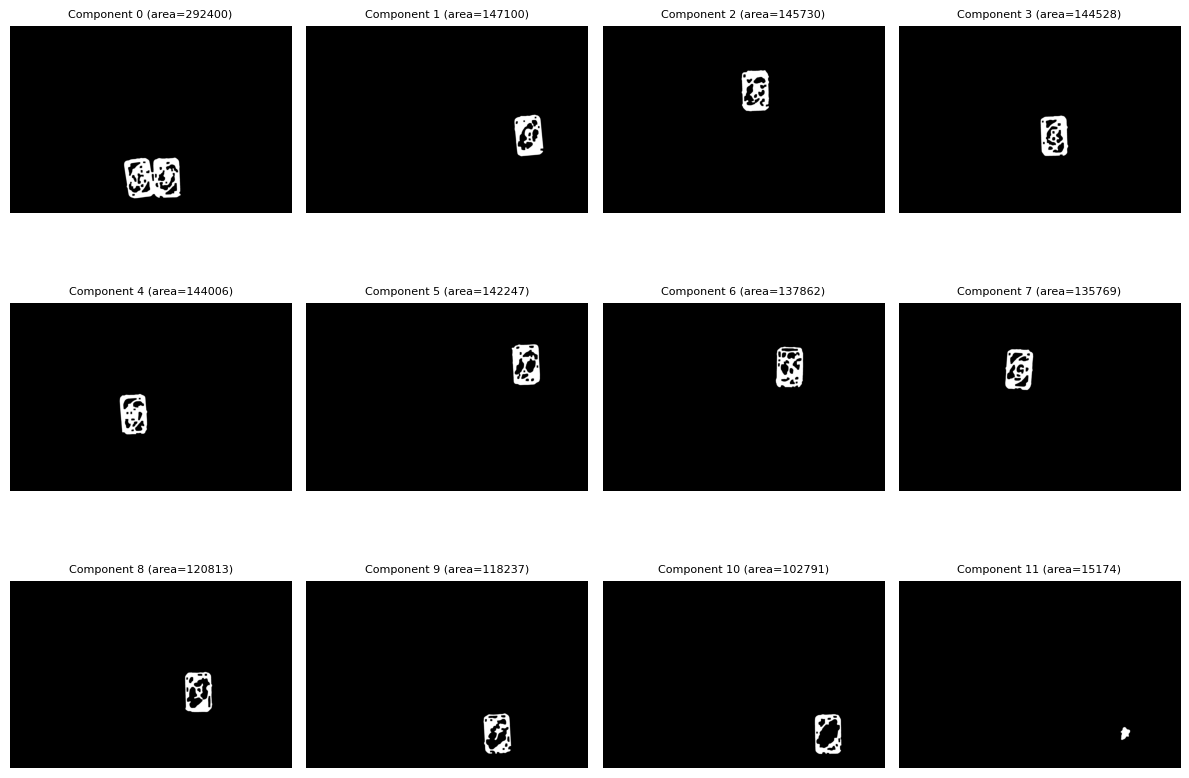

Total components found (excl. background): 18


In [115]:
masks = binary.copy()
# Close holes within each card without bridging the gaps between cards
kernel = np.ones((21, 21), np.uint8)
masks = cv2.morphologyEx(masks, cv2.MORPH_CLOSE, kernel)
kernel = np.ones((7, 7), np.uint8)
masks = cv2.morphologyEx(masks, cv2.MORPH_OPEN, kernel)

# Separate connected components and keep the 12 largest ones
n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(masks, connectivity=8)

# stats[i] = [x, y, w, h, area]; label 0 is the background, skip it
areas = stats[1:, cv2.CC_STAT_AREA]
top12_idx = np.argsort(areas)[::-1][:12] + 1  # +1 to offset skipped background

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for plot_i, label_idx in enumerate(top12_idx):
    component_mask = (labels == label_idx).astype(np.uint8) * 255
    cv2.imwrite(os.path.join(components_dir, f"component_{plot_i}.jpg"), component_mask)
    axes[plot_i // 4][plot_i % 4].imshow(component_mask, cmap='gray')
    axes[plot_i // 4][plot_i % 4].set_title(f"Component {plot_i} (area={areas[label_idx-1]})", fontsize=8)
    axes[plot_i // 4][plot_i % 4].axis('off')

plt.tight_layout()
plt.show()
print(f"Total components found (excl. background): {n_labels - 1}")

In [116]:
# morphologically close each component then save
for plot_i, label_idx in enumerate(top12_idx):
    component_mask = (labels == label_idx).astype(np.uint8) * 255
    closed_mask = cv2.morphologyEx(component_mask, cv2.MORPH_CLOSE, np.ones((133, 133), np.uint8))
    cv2.imwrite(os.path.join(closed_dir, f"closed_component_{plot_i}.jpg"), closed_mask)

In [117]:
# Load the original color image for cropping
img_color = cv2.imread(os.path.join(ref, f"{img_name}.jpg"))

for plot_i, label_idx in enumerate(top12_idx):
    closed_mask = cv2.imread(os.path.join(closed_dir, f"closed_component_{plot_i}.jpg"), cv2.IMREAD_GRAYSCALE)
    x, y, w, h = cv2.boundingRect(closed_mask)
    cropped_img = img_color[y:y+h, x:x+w]
    cv2.imwrite(os.path.join(crops_dir, f"crop_{plot_i}.jpg"), cropped_img)